In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
import pandas_datareader.data as web
import datetime
import os
import matplotlib.pyplot as plt
import plotly
import time
from datetime import datetime

In [25]:
#실현변동성 함수
def realized_volatility(x):
    return np.sqrt((x**2).sum())

#특이값 탐지 함수
def identify_outliers(row, n_sigmas=3):
    x = row['simple_rtn']
    mu = row['mean']
    sigma = row['std']

    if (x > mu + n_sigmas * sigma) or (x < mu - n_sigmas * sigma):
        return 1
    else:
        return 0

In [26]:
#현재 디렉토리 경로
dirNm = "dailyStock"
vspwd = os.getcwd()

#디렉토리 재설정
os.chdir(vspwd)

In [33]:
target="^GSPC" #S&P500 지수
file_path = f"{dirNm}/{target}.csv"

targetDf =  pd.read_csv(file_path, encoding="utf-8")
targetDf['Date'] = pd.to_datetime(targetDf['Date'])
targetDf = targetDf.set_index("Date")

targetDf['simple_rtn']=targetDf.adj_close.pct_change()                 #단순 수익률
targetDf['log_rtn']=np.log(targetDf.adj_close/targetDf.adj_close.shift(1))   #로그 수익률

#### 실현변동 계산

C:\Users\ckddn\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


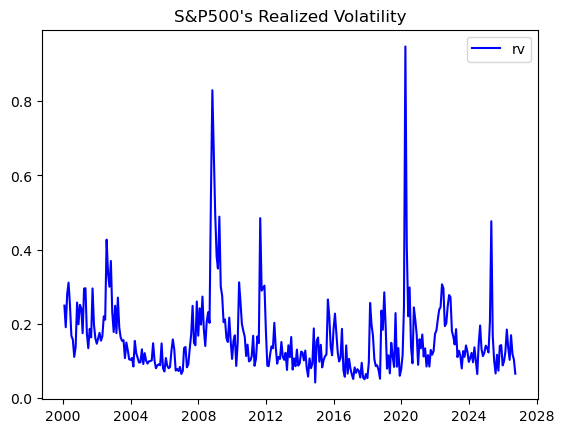

In [35]:
df_rv= targetDf.groupby(pd.Grouper(freq='ME')).apply(realized_volatility)
df_rv.rename (columns={'log_rtn':'rv'}, inplace=True)

df_rv.rv = df_rv.rv * np.sqrt(12)

fig, ax = plt.subplots()

ax.plot(df_rv.index, df_rv.rv, color='blue', label='rv')
ax.set_title("S&P500's Realized Volatility")
ax.legend(loc='upper right')

#### 특이값 식별

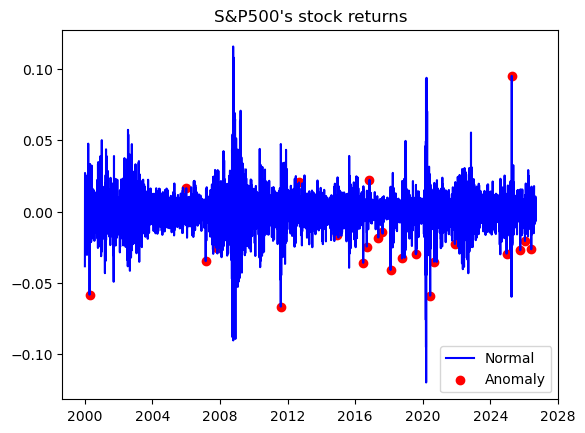

In [36]:
# 1.롤링 평균, 표준편차계산
df_rolling=targetDf[['simple_rtn']].rolling(window=21).agg(['mean', 'std'])
df_rolling.columns = df_rolling.columns.droplevel()

# 2.롱링 척도 join
df_outliers = targetDf.join(df_rolling)

# 3. 이상값 여부 체크
df_outliers['outlier'] = df_outliers.apply(identify_outliers,axis=1)

# 4. 이상값만 추출
outliers = df_outliers.loc[df_outliers['outlier'] == 1,['simple_rtn']]

fig, ax = plt.subplots()

ax.plot(df_outliers.index, df_outliers.simple_rtn, color='blue', label='Normal')
ax.scatter(outliers.index, outliers.simple_rtn, color='red', label='Anomaly')
ax.set_title("S&P500's stock returns")
ax.legend(loc='lower right')

#### 주가 시계열 시각화

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Log returns ($)')]

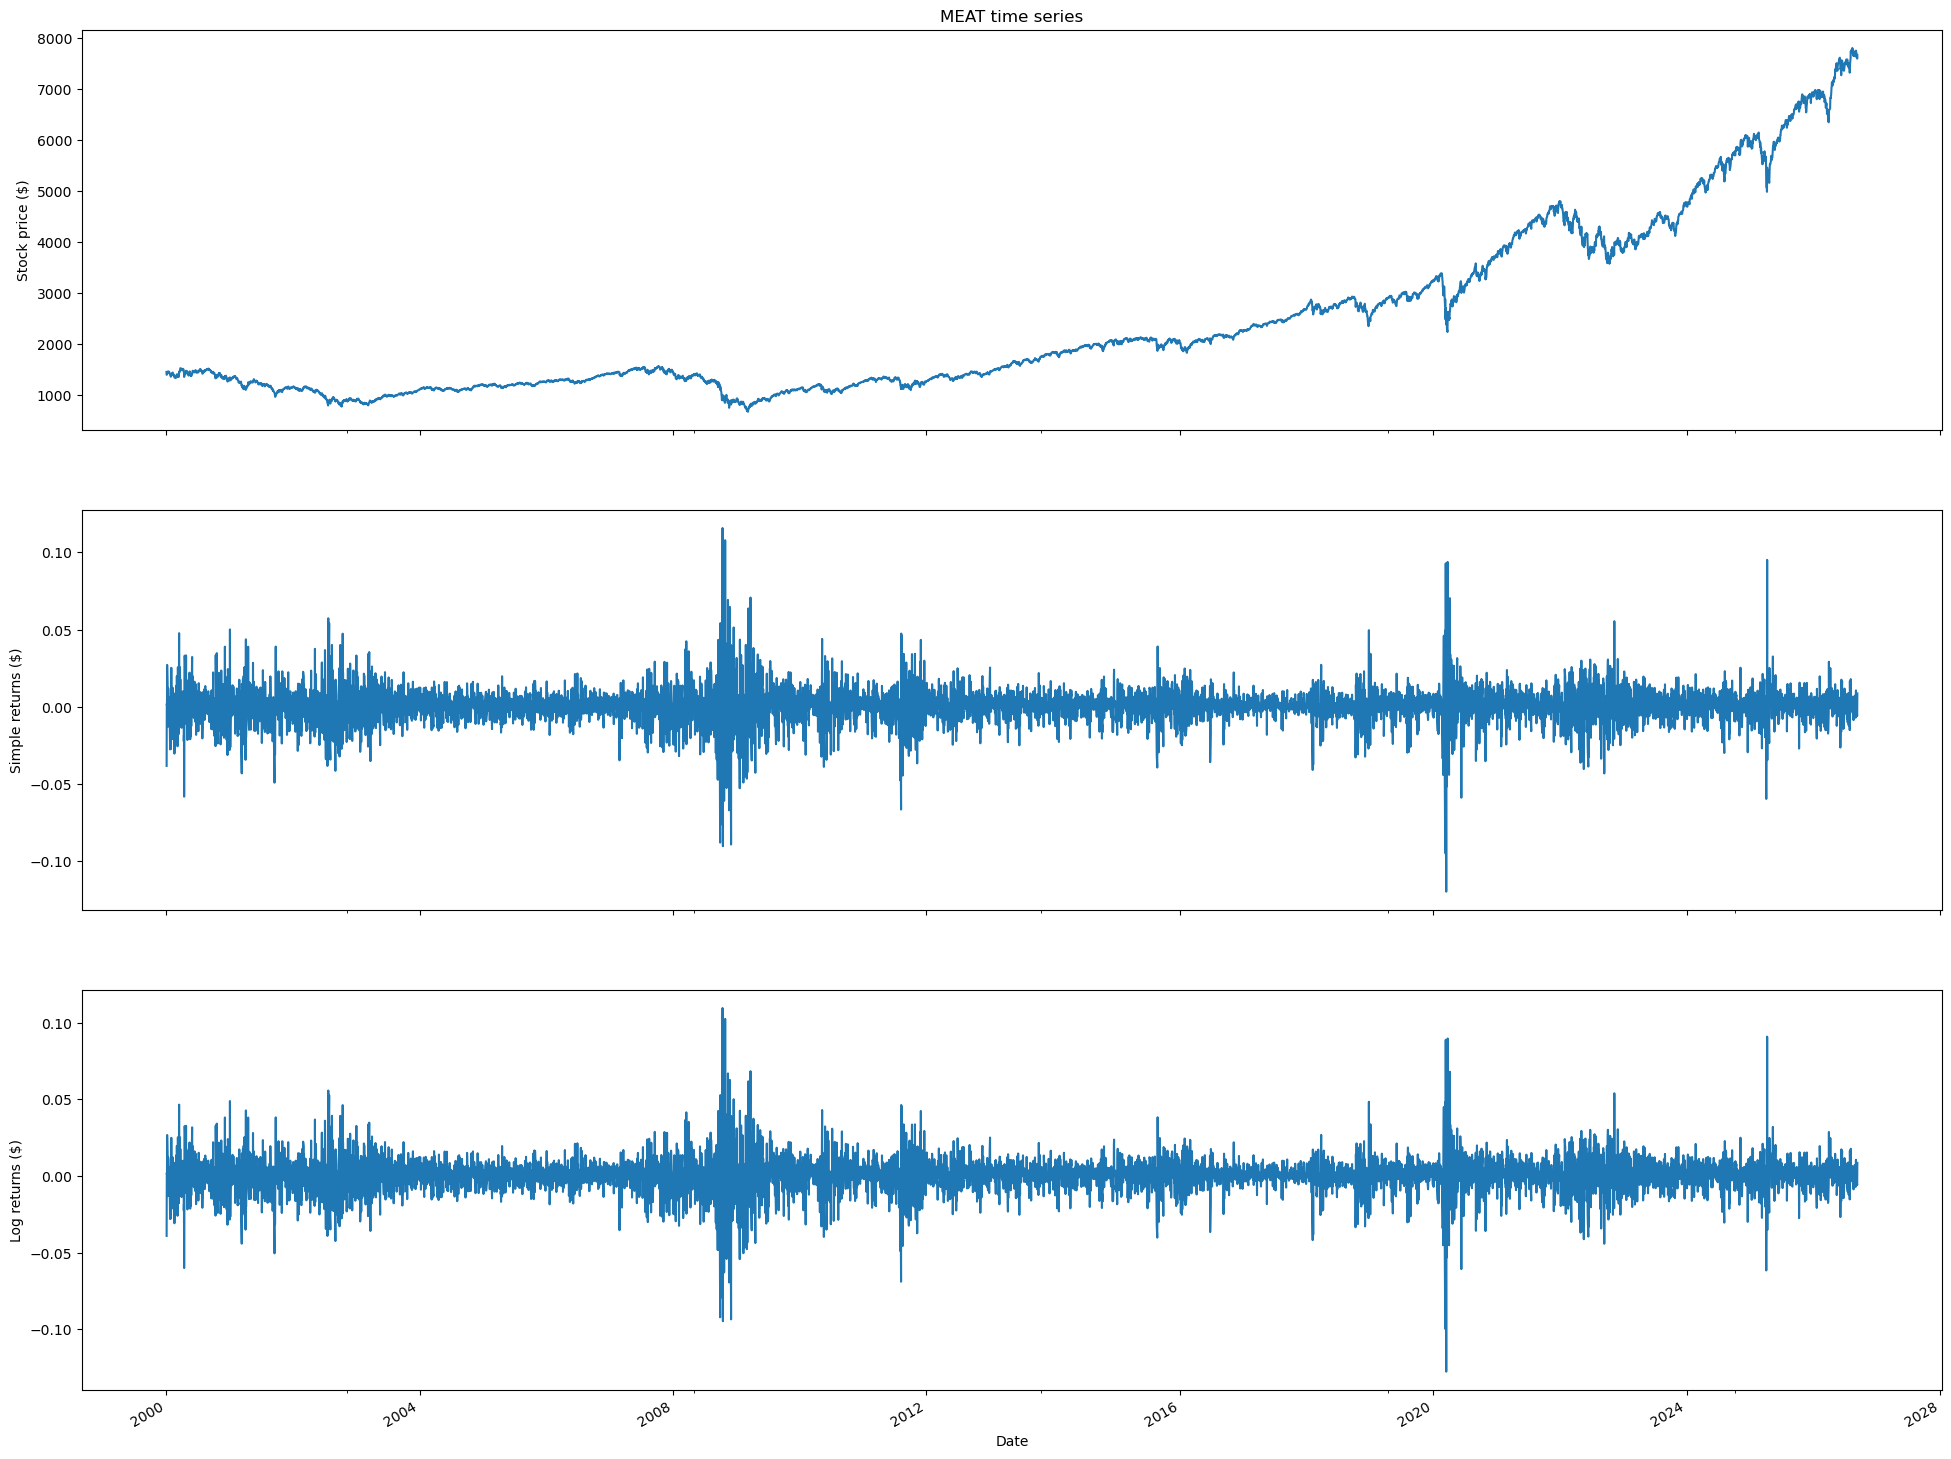

In [37]:
fig, ax = plt.subplots(3,1, figsize=(24, 20),sharex=True)

#조정 주가 시계열
targetDf.adj_close.plot(ax=ax[0])
ax[0].set(title='MEAT time series', ylabel= 'Stock price ($)')

#단순 수익률 시계열
targetDf.simple_rtn.plot(ax=ax[1])
ax[1].set(ylabel= 'Simple returns ($)')

#로그 수익률 시계열
targetDf.log_rtn.plot(ax=ax[2])
ax[2].set(xlabel='Date', ylabel= 'Log returns ($)')